# apo V0.1

# Related notebooks(関連するnotebook)
|name|github|kaggle|
|-----|-----|-----|
|Data confirmation file(データ確認ファイル)|[study.ipynb](https://github.com/kenkenkengo0421/Muscle_Architecture_in_Ultrasound_Data/blob/main/study.ipynb)|https://www.kaggle.com/code/nagatakengo/study|
|Consistency investigation regarding image size differences(画像サイズ違いについての整合調査)|[Imagesize_investigation.ipynb](https://github.com/kenkenkengo0421/Muscle_Architecture_in_Ultrasound_Data/blob/main/Imagesize_investigation.ipynb)|https://www.kaggle.com/code/nagatakengo/imagesize-investigation|




In [1]:
!mkdir -p content/my_dataset
!unzip -q umud-challenge-muscle-architecture-in-ultrasound-data.zip -d content/my_dataset/

"""
import sys
sys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")
!pip uninstall -y -q torch torchvision torchaudio > /dev/null 2>&1
!pip install -q --no-cache-dir \
    torch==2.10.0 \
    torchvision==0.25.0 \
    torchaudio==2.10.0 \
    --index-url https://download.pytorch.org/whl/cu126 \
    > /dev/null 2>&1
"""

'\nimport sys\nsys.path.append("/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data")\n'

## 1　Definition of functions and libraries(関数、ライブラリの定義)

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split


def load_apo_binary_mask(mask_dir, file_name):
    """
    apo mask を
    背景=0
    aponeurosis=1
    の二値配列に変換する
    """
    mask = Image.open(os.path.join(mask_dir, file_name))
    mask_array = np.array(mask)

    if mask.mode == "P":
        binary_mask = (mask_array == 0).astype(np.uint8)
    elif mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)
    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")
    return binary_mask


def load_fasc_binary_mask(mask_dir, file_name):
    """
    fasc mask を
    背景=0
    fascicle=1
    の二値配列に変換する
    """
    mask = Image.open(os.path.join(mask_dir, file_name))
    mask_array = np.array(mask)

    if mask.mode == "L":
        binary_mask = (mask_array == 255).astype(np.uint8)
    else:
        raise ValueError(f"未対応のmodeです: {mask.mode}")
    return binary_mask


data_dir = "content/my_dataset"
#data_dir = "/kaggle/input/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"

apo_images_new_model_v1 = os.path.join(
    data_dir,
    "apo_imgs_v1",
    "apo_images_new_model_v1"
)
apo_masks_new_model_v1 = os.path.join(
    data_dir,
    "apo_masks_v1",
    "apo_masks_new_model_v1"
)


class ApoDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith(
                (".tif", ".tiff", ".png", ".jpg", ".jpeg")
            )
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        file_name = self.image_files[index]
        image_path = os.path.join(self.image_dir, file_name)

        image = Image.open(image_path).convert("RGB")
        mask = load_apo_binary_mask(self.mask_dir, file_name)

        #maskとimageをサイズ揃える
        mask = Image.fromarray(mask)
        mask = mask.resize(
            image.size,
            resample=Image.Resampling.NEAREST
        )
        image, mask = resize_with_padding(
            image,
            mask,
            target_size=(768, 512)
        )

        # image → numpy → Tensor
        image = np.array(image)
        image = torch.from_numpy(image).float() / 255.0
        image = image.permute(2, 0, 1)

        # mask → numpy → Tensor
        mask = np.array(mask)
        mask = torch.from_numpy(mask).float()
        mask = mask.unsqueeze(0)

        return image, mask


def resize_with_padding(image, mask, target_size=(768, 512)):
    """
    image と mask の縦横比を維持したまま縮小し、
    target_size まで余白を追加する
    """

    target_width, target_height = target_size
    original_width, original_height = image.size
    scale = min(
        target_width / original_width,
        target_height / original_height
    )
    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    # image を縮小
    image = image.resize(
        (new_width, new_height),
        resample=Image.Resampling.BILINEAR
    )

    # mask を同じサイズへ縮小
    mask = mask.resize(
        (new_width, new_height),
        resample=Image.Resampling.NEAREST
    )

    # 余白の位置
    left = (target_width - new_width) // 2
    top = (target_height - new_height) // 2

    # image 用canvas
    image_canvas = Image.new(image.mode, target_size, 0)

    # mask 用canvas
    mask_canvas = Image.new("L", target_size, 0)

    # 同じ位置へ配置
    image_canvas.paste(image, (left, top))
    mask_canvas.paste(mask, (left, top))

    return image_canvas, mask_canvas


import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # 出力
        self.output = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        dec4 = self.up4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec4(dec4)

        dec3 = self.up3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.up2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.up1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec1(dec1)

        return self.output(dec1)

## 2　Settings and confirmation(設定と確認)

In [3]:
apo_dataset = ApoDataset(
    apo_images_new_model_v1,
    apo_masks_new_model_v1
)

train_size = int(len(apo_dataset) * 0.8)
val_size = len(apo_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    apo_dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False
)

print("=============================================")
print("全データ:", len(apo_dataset))
print("train:", len(train_dataset))
print("validation:", len(val_dataset))

apo_loader = DataLoader(
    apo_dataset,
    batch_size=4,
    shuffle=True
)

images, masks = next(iter(apo_loader))

print("=============================================")
print("image min:", images.min())
print("image max:", images.max())
print("mask unique:", torch.unique(masks))

print("=============================================")
print("images shape:", images.shape)
print("masks shape:", masks.shape)
print("masks unique:", torch.unique(masks))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)

全データ: 1048
train: 838
validation: 210
image min: tensor(0.)
image max: tensor(1.)
mask unique: tensor([0., 1.])
images shape: torch.Size([4, 3, 512, 768])
masks shape: torch.Size([4, 1, 512, 768])
masks unique: tensor([0., 1.])
device: cuda


## 3　learning training(学習)

In [4]:
apo_model = UNet()                                      #モデル
apo_model = apo_model.to(device)

criterion = nn.BCEWithLogitsLoss()                      #U-Netの予測─正解maskとどれくらい違うか計算-loss

optimizer = torch.optim.Adam(
    apo_model.parameters(),                             #U-Netの学習対象パラメータ
    lr=0.001                                            #1回の更新幅
)


#学習

num_epochs = 5

for epoch in range(num_epochs):

    apo_model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = apo_model(images)

        loss = criterion(outputs, masks)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)


    # validation

    apo_model.eval()
    val_total_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = apo_model(images)

            loss = criterion(outputs, masks)

            val_total_loss += loss.item()

    val_loss = val_total_loss / len(val_loader)


    print("=============================================")
    print(f"epoch: {epoch + 1}/{num_epochs}")
    print("train loss:", train_loss)
    print("validation loss:", val_loss)


# 学習結果保存

print(f"""
=================================================
train loss: {train_loss}
validation loss: {val_loss}
=================================================
""")

with open("log.txt", "a") as f:
    f.write(f"train loss: {train_loss}\n")
    f.write(f"validation loss: {val_loss}\n")

torch.save(
    apo_model.state_dict(),
    "apo_model.pth"
)

print("ログとモデルを保存しました")

epoch: 1/5
train loss: 0.1057603148241174
validation loss: 0.07999145179277374
epoch: 2/5
train loss: 0.09691408476158798
validation loss: 0.06523182856894674
epoch: 3/5
train loss: 0.06361344190834531
validation loss: 0.06319563436721053
epoch: 4/5
train loss: 0.058341176566936805
validation loss: 0.05605516660781134
epoch: 5/5
train loss: 0.05516191868462682
validation loss: 0.05377032022391047

train loss: 0.05516191868462682
validation loss: 0.05377032022391047

ログとモデルを保存しました


## 4　Visualize and evaluate model accuracy(モデルの精度を可視化と評価)

apo_modelを読み込みました
device: cuda
Dice: 0.5936030622368201
IoU: 0.42207363106245305


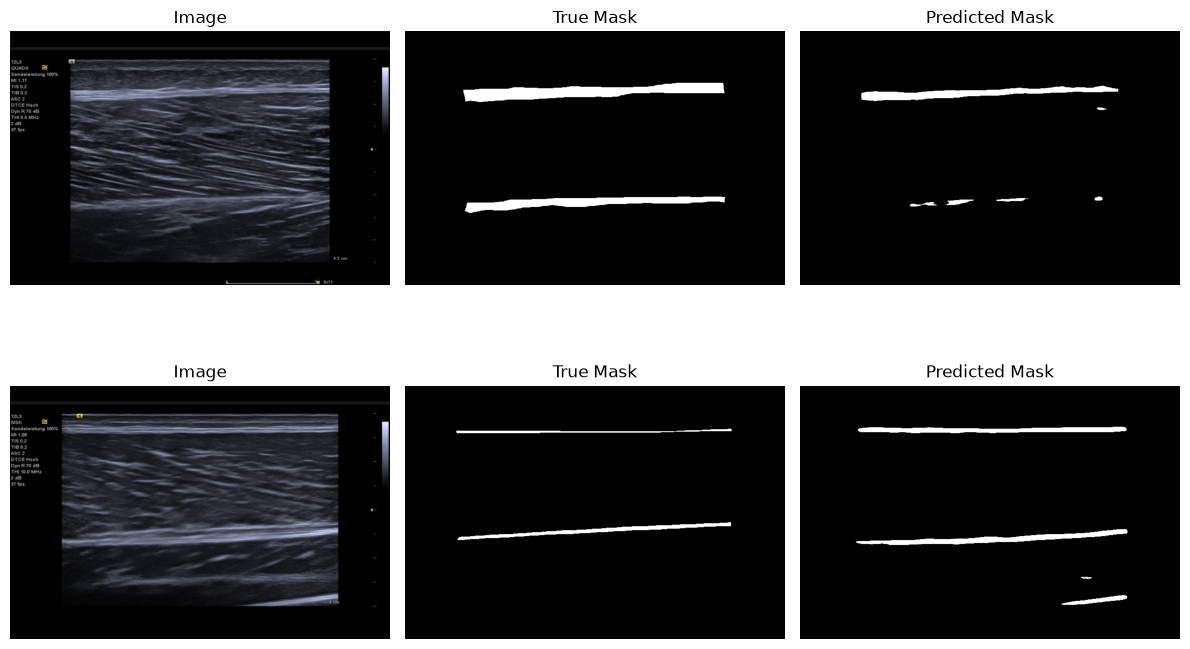

In [6]:
# 保存済みapoモデルを読み込む

apo_model = UNet()

apo_model.load_state_dict(
    torch.load(
        "apo_model.pth",
        map_location=device
    )
)

apo_model = apo_model.to(device)

apo_model.eval()

print("apo_modelを読み込みました")
print("device:", device)


# Dice / IoU

intersection_total = 0
pred_total = 0
true_total = 0
union_total = 0

with torch.no_grad():

    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = apo_model(images)

        # logits → 確率
        pred_probs = torch.sigmoid(outputs)

        # 0.5以上をapo=1
        pred_masks = (pred_probs >= 0.5).float()

        intersection_total += (
            pred_masks * masks
        ).sum().item()

        pred_total += pred_masks.sum().item()
        true_total += masks.sum().item()

        union_total += (
            ((pred_masks + masks) > 0)
            .float()
            .sum()
            .item()
        )


dice = (
    2 * intersection_total
) / (
    pred_total + true_total
)

iou = intersection_total / union_total


print("=============================================")
print("Dice:", dice)
print("IoU:", iou)


images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = apo_model(images)

# logits → 確率
pred_probs = torch.sigmoid(outputs)

# 0.5以上をapo=1
pred_masks = (pred_probs >= 0.5).float()


# CPUへ戻す
images = images.cpu()
masks = masks.cpu()
pred_masks = pred_masks.cpu()


# 表示
num_samples = min(2, len(images))

fig, axes = plt.subplots(
    num_samples,
    3,
    figsize=(12, 4 * num_samples)
)

for i in range(num_samples):

    # 元画像
    image = images[i].permute(1, 2, 0).numpy()

    # 正解mask
    true_mask = masks[i, 0].numpy()

    # 予測mask
    pred_mask = pred_masks[i, 0].numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(true_mask, cmap="gray")
    axes[i, 1].set_title("True Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title("Predicted Mask")
    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()
